In [ ]:
# importar librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

In [ ]:
# descargar datos
df = pd.read_csv('/content/sample_data/gym_churn_us.csv')

# Analisis exploratorio de datos (EDA)


In [ ]:
# visualizacion rapida de la estructura de los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [ ]:
# reformatear nombres de columnas
df.columns = df.columns.str.lower()

In [ ]:
print(df.describe())

            gender  near_location      partner  promo_friends        phone  \
count  4000.000000    4000.000000  4000.000000    4000.000000  4000.000000   
mean      0.510250       0.845250     0.486750       0.308500     0.903500   
std       0.499957       0.361711     0.499887       0.461932     0.295313   
min       0.000000       0.000000     0.000000       0.000000     0.000000   
25%       0.000000       1.000000     0.000000       0.000000     1.000000   
50%       1.000000       1.000000     0.000000       0.000000     1.000000   
75%       1.000000       1.000000     1.000000       1.000000     1.000000   
max       1.000000       1.000000     1.000000       1.000000     1.000000   

       contract_period  group_visits          age  \
count      4000.000000   4000.000000  4000.000000   
mean          4.681250      0.412250    29.184250   
std           4.549706      0.492301     3.258367   
min           1.000000      0.000000    18.000000   
25%           1.000000      0.00

In [ ]:
print(df.head())

   gender  near_location  partner  promo_friends  phone  contract_period  \
0       1              1        1              1      0                6   
1       0              1        0              0      1               12   
2       0              1        1              0      1                1   
3       0              1        1              1      1               12   
4       1              1        1              1      1                1   

   group_visits  age  avg_additional_charges_total  month_to_end_contract  \
0             1   29                     14.227470                    5.0   
1             1   31                    113.202938                   12.0   
2             0   28                    129.448479                    1.0   
3             1   33                     62.669863                   12.0   
4             0   26                    198.362265                    1.0   

   lifetime  avg_class_frequency_total  avg_class_frequency_current_month  \
0  

In [ ]:
# caracteristicas promedio por grupo
# 0 - clientes que mantienen su membresia
# 1 - clientes que cancelaron su membresia
mean_charact_by_group = df.groupby('churn').mean()
print(mean_charact_by_group)

         gender  near_location   partner  promo_friends     phone  \
churn                                                               
0      0.510037       0.873086  0.534195       0.353522  0.903709   
1      0.510839       0.768143  0.355325       0.183789  0.902922   

       contract_period  group_visits        age  avg_additional_charges_total  \
churn                                                                           
0             5.747193      0.464103  29.976523                    158.445715   
1             1.728558      0.268615  26.989632                    115.082899   

       month_to_end_contract  lifetime  avg_class_frequency_total  \
churn                                                               
0                   5.283089  4.711807                   2.024876   
1                   1.662582  0.990575                   1.474995   

       avg_class_frequency_current_month  
churn                                     
0                               2.0

En primera instancia, podemos observar discrepancias en el promedio de varias características cuando agrupamos los clientes que recién cancelaron y clientes actuales.

- El 87% de los clientes actuales cuentan con una cercanía al gimnasio, mientras que para los clientes que cancelaron su membresía es de casi 77%.

- El hecho de que la empresa del usuario esté asociada con el gimnasio baja hasta el 35% para aquellos clientes que cancelaron, mientras que el 53% de los clientes que conservan su membresía son empleados en empresas asociadas con el gimnasio.

- También los clientes con membresía tienen un contrato promedio de casi 6 meses y los clientes que cancelan contaban con un contrato promedio de casi 2 meses.

- Los clientes que cancelan su membresía promedian apenas 1 mes inscritos en el gimnasio, a diferencia de los que conservan su membresía, que promedian casi 5 meses inscritos.

- Finalmente, durante su último mes, los clientes que cancelan su membresía, en promedio, asisten 1 vez por semana, contrastado con 2 veces por semana en promedio para los clientes que no cancelan su membresía.

In [ ]:
# matriz de caracteristicas
X = df.drop('churn', axis=1)

# variable objetivo
y = df['churn']

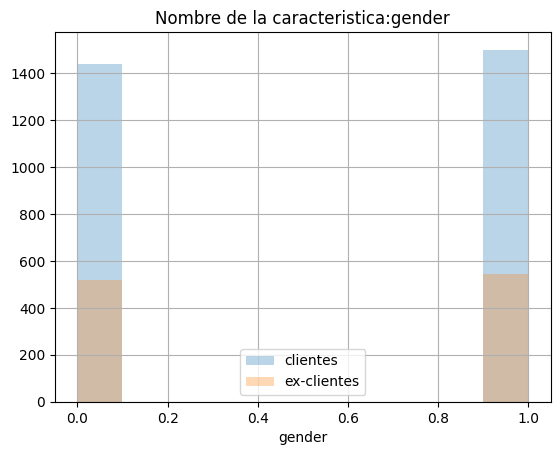

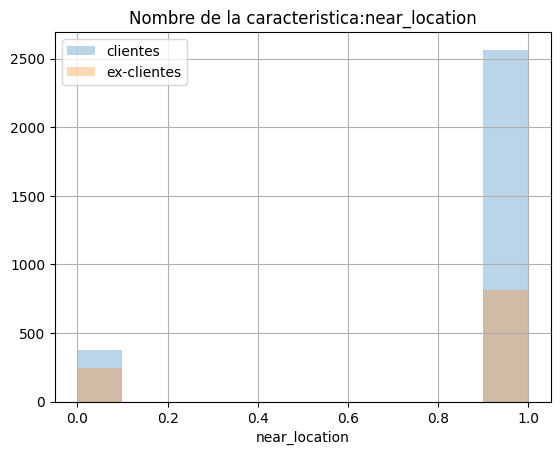

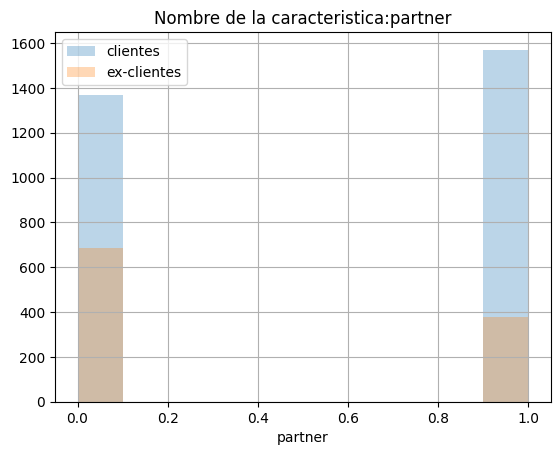

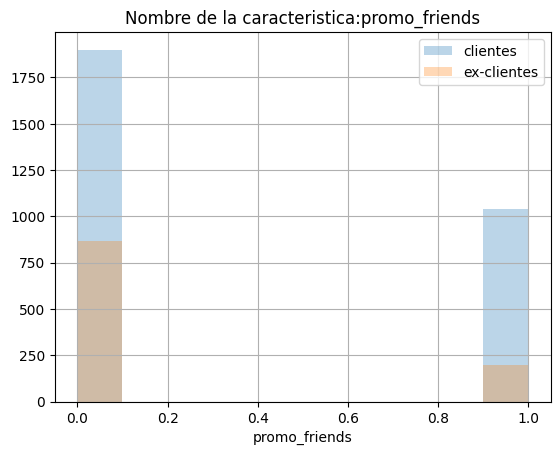

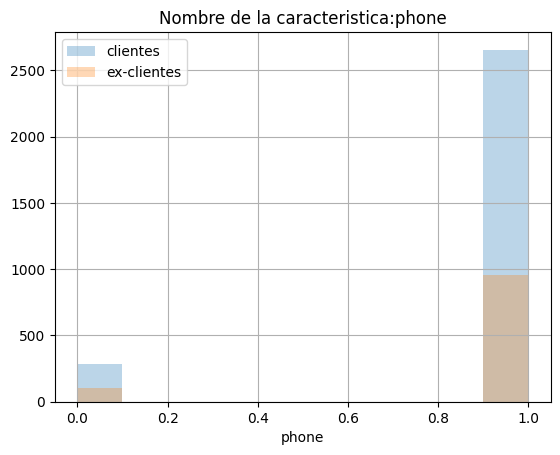

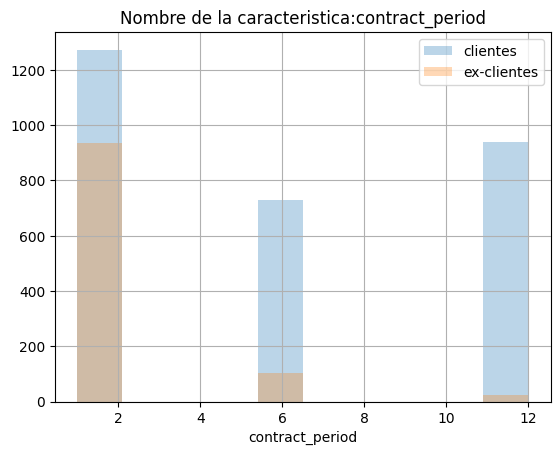

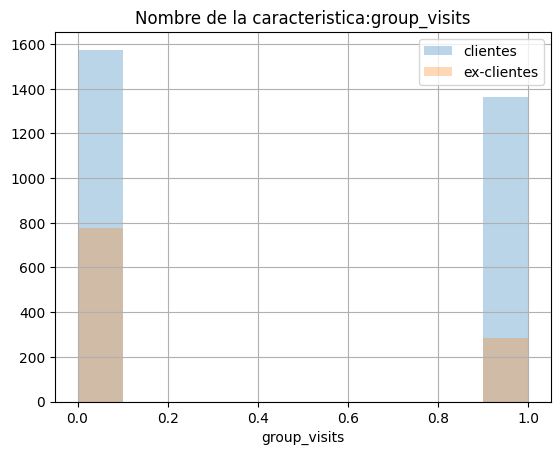

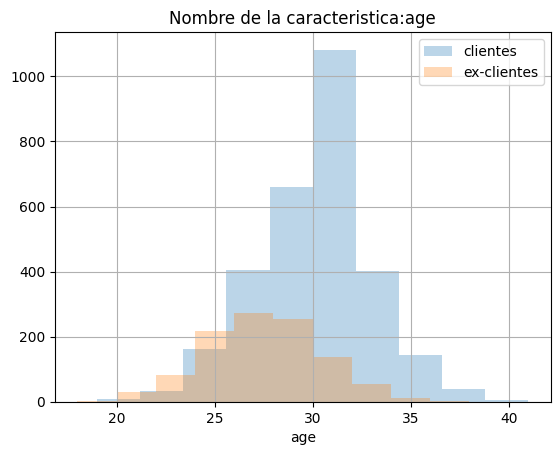

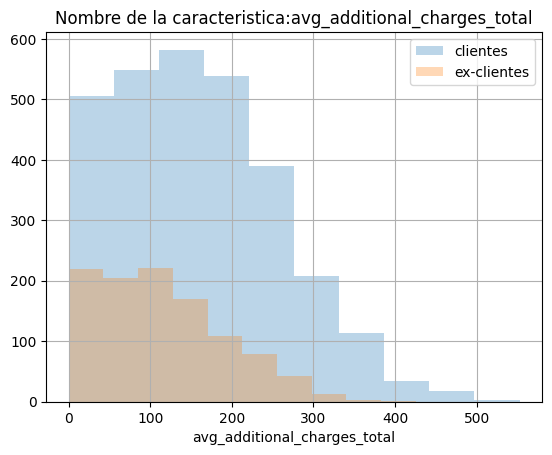

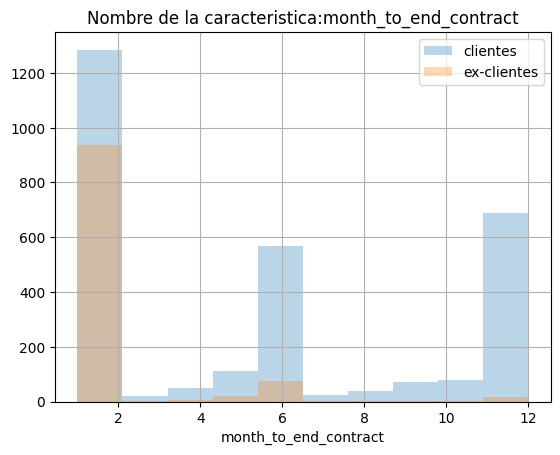

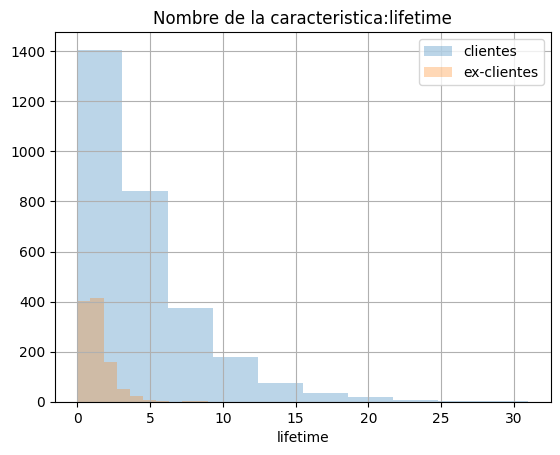

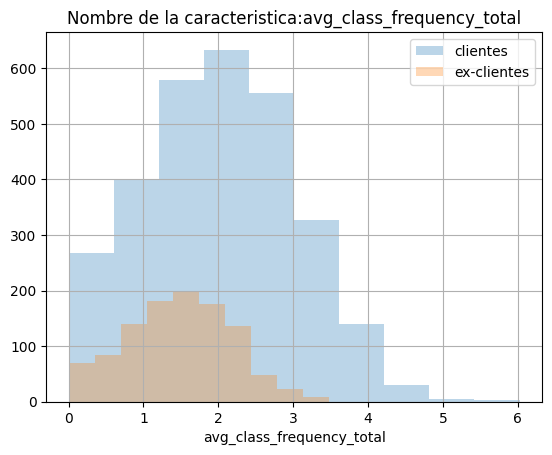

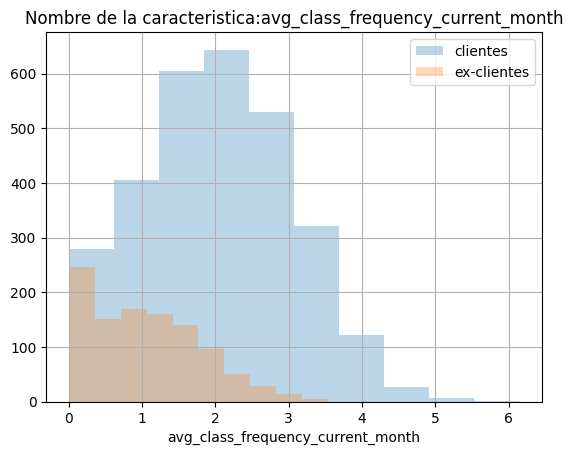

In [ ]:
# separamos el DataFrame en clientes
clients = df[df['churn'] == 0]
# y ex clientes
ex_clients = df[df['churn'] == 1]

# histogramas de caracteristicas por grupo
for column in X.columns:
  clients[column].hist(alpha=0.3, label='clientes')
  ex_clients[column].hist(alpha=0.3, label='ex-clientes')
  plt.title(f'Nombre de la caracteristica:{column}')
  plt.xlabel(column)
  plt.legend()
  plt.show()

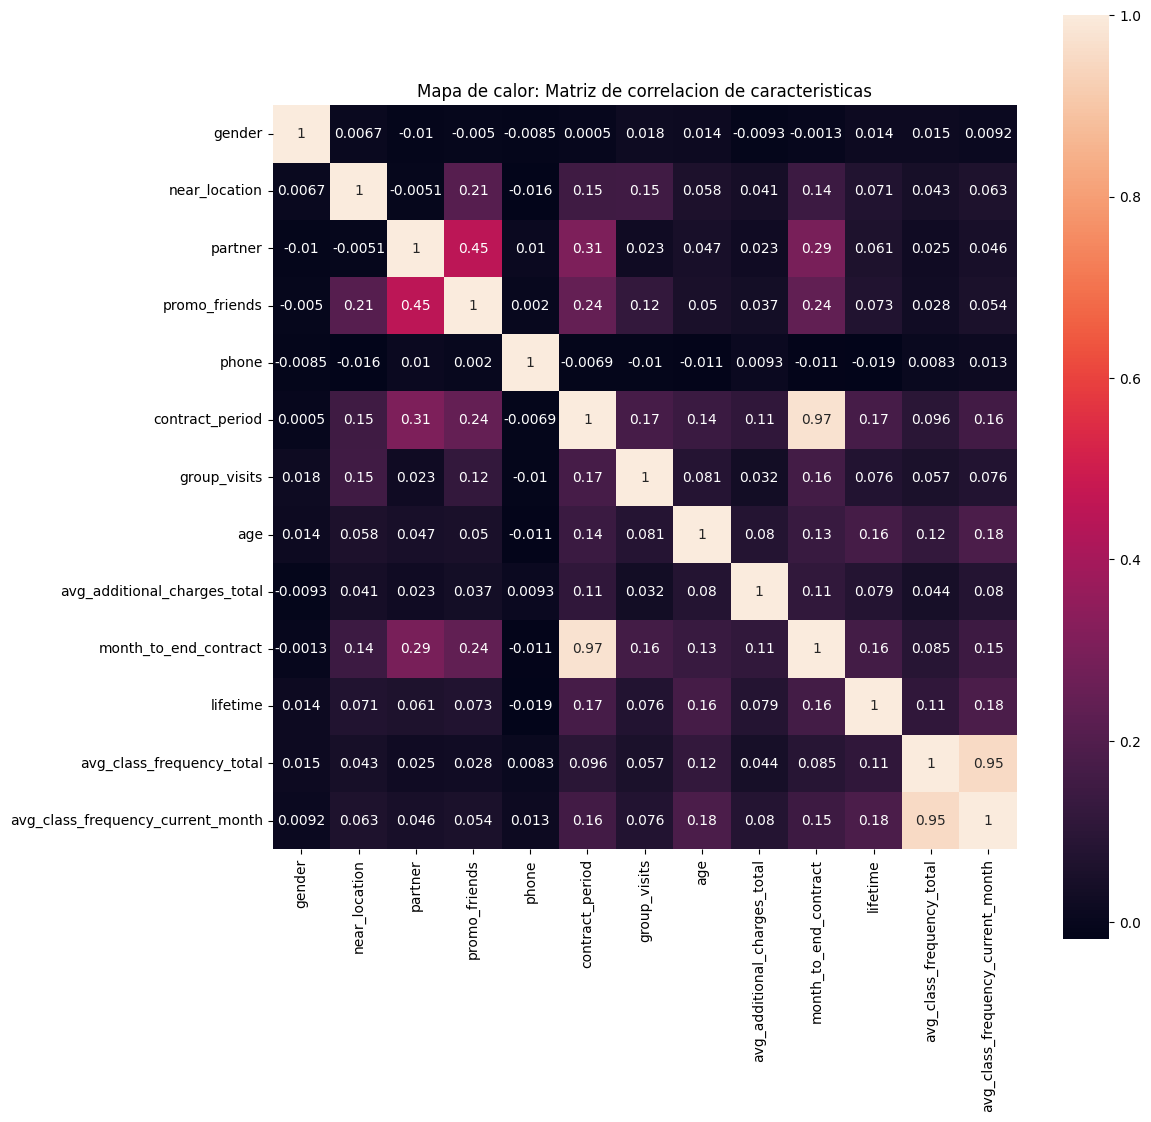

In [ ]:
# matriz de correlacion
corr_matrix = X.corr()

# visualizacion de matriz de correlacion
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=True, square=True)
plt.title('Mapa de calor: Matriz de correlacion de caracteristicas')

plt.show()

Observamos una correlación muy fuerte (0.95) entre las columnas 'avg_class_frequency_total' y 'avg_class_frequency_current_month', eliminaremos la  'avg_class_frequency_current_month' para evitar sesgo en el análisis.

In [ ]:
# eliminar 'avg_class_frequency_current_month' de la matriz de caracteristicas
X.drop('avg_class_frequency_current_month', axis=1, inplace=True)

# Construccion de modelo para predecir la cancelacion de  usuarios


In [ ]:
# preprocesamiento de los datos

# separacion de matriz y variable objetivo en sets de entrenamiento y validacion
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# estandarizacion de los datos
scaler = StandardScaler()
X_train_st = scaler.fit_transform(X_train)

X_test_st = scaler.transform(X_test)

In [ ]:
# modelo: Regresion logistica
lr_model = LogisticRegression(random_state=0)
# entrenar modelo
lr_model.fit(X_train_st, y_train)

# prediccion
lr_predictions = lr_model.predict(X_test_st)
# probabilidad
lr_probabilities = lr_model.predict_proba(X_test_st)[:, 1]

In [ ]:
# modelo: Bosque aleatorio
rf_model = RandomForestClassifier(n_estimators=100, random_state=0)
# entrenar modelo
rf_model.fit(X_train_st, y_train)

rf_predictions = rf_model.predict(X_test_st)
rf_probabilities = rf_model.predict_proba(X_test_st)[:, 1]

In [ ]:
# funcion para mostrar las metricas del modelo
def print_all_metrics(y_true, y_pred, y_proba, model_name):
  print(model_name)
  print('\tExactitud: {:.2f}'.format(accuracy_score(y_true, y_pred)))
  print('\tPrecision: {:.2f}'.format(precision_score(y_true, y_pred)))
  print('\tRecall: {:.2f}'.format(recall_score(y_true, y_pred)))

In [ ]:
# mostrar metricas del modelo de regresion logistica
print_all_metrics(y_test, lr_predictions, lr_probabilities, 'Regresion Logistica')

print('\n')

# mostrar metricas del modelo de bosque aleatorio
print_all_metrics(y_test, rf_predictions, rf_probabilities, 'Bosque Aleatorio')

Regresion Logistica
	Exactitud: 0.90
	Precision: 0.78
	Recall: 0.81


Bosque Aleatorio
	Exactitud: 0.89
	Precision: 0.80
	Recall: 0.76


Métricas muy similares para ambos modelos; ambos cuentan con un muy buen desempeño. En esta tarea particular, el modelo de regresión logística cuenta con métricas más fuertes, indicando un mejor rendimiento para el modelo.

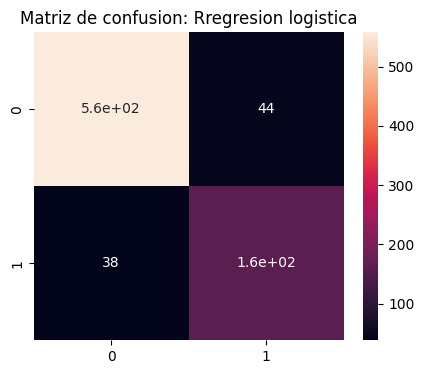

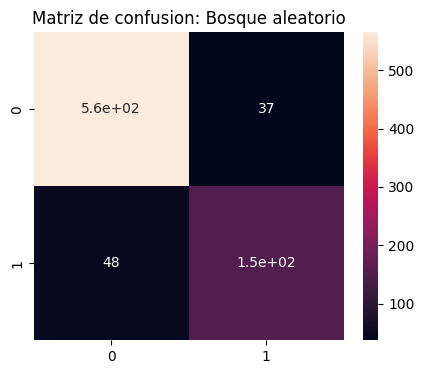

In [ ]:
# matriz de confusion Regresion logistica
lr_cm = confusion_matrix(y_test, lr_predictions)
plt.figure(figsize=(5, 4))
sns.heatmap(lr_cm, annot=True)
plt.title('Matriz de confusion: Regresion logistica')
plt.show()

# matriz de confusion Bosque aleatorio
rf_cm = confusion_matrix(y_test, rf_predictions)
plt.figure(figsize=(5, 4))
sns.heatmap(rf_cm, annot=True)
plt.title('Matriz de confusion: Bosque aleatorio')
plt.show()


Con las matrices de confusión terminamos de concluir qué modelo cometió menos errores. Por un lado, tenemos el modelo de regresión logística con un falso positivo de 44 y falso negativo de 38 para un total de 82 errores. Por el otro lado, el modelo de bosque aleatorio cuenta con 37 falsos positivos y 48 falsos negativos, sumando 85 errores.

# Crear clusteres de usuarios

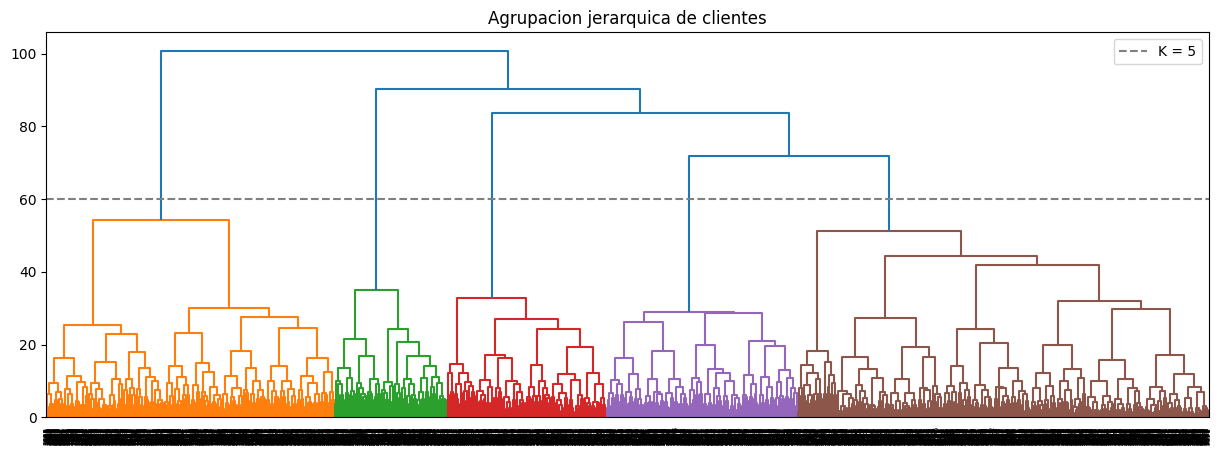

In [ ]:
# estandarizar datos
sc = StandardScaler()
X_sc = sc.fit_transform(X)

linked = linkage(X_sc, method='ward')

# mostrar dendrograma
plt.figure(figsize=(15, 5))
dendrogram(linked)
# trazar linea para definir K
plt.axhline(y=60, linestyle='--', color='grey', label='K = 5')
plt.title('Agrupacion jerarquica de clientes')
plt.legend()
plt.show()#

En el dendrograma podemos ver ya una sugerencia en función de los colores para el número de clusters que podemos definir para el modelo K-Means; si trazamos una línea a la altura 60, podemos encontrar 5 líneas verticales (K = 5), que es justamente el número de colores que pinta el gráfico.

In [ ]:
# modelo K-Means
km = KMeans(n_clusters=5)

# predicciones
labels = pd.Series(km.fit_predict(X_sc), name='label')

In [ ]:
# agregamos las etiquetas predicha spor el modelo al df original
df['label'] = labels
print(df.head())

   gender  near_location  partner  promo_friends  phone  contract_period  \
0       1              1        1              1      0                6   
1       0              1        0              0      1               12   
2       0              1        1              0      1                1   
3       0              1        1              1      1               12   
4       1              1        1              1      1                1   

   group_visits  age  avg_additional_charges_total  month_to_end_contract  \
0             1   29                     14.227470                    5.0   
1             1   31                    113.202938                   12.0   
2             0   28                    129.448479                    1.0   
3             1   33                     62.669863                   12.0   
4             0   26                    198.362265                    1.0   

   lifetime  avg_class_frequency_total  avg_class_frequency_current_month  \
0  

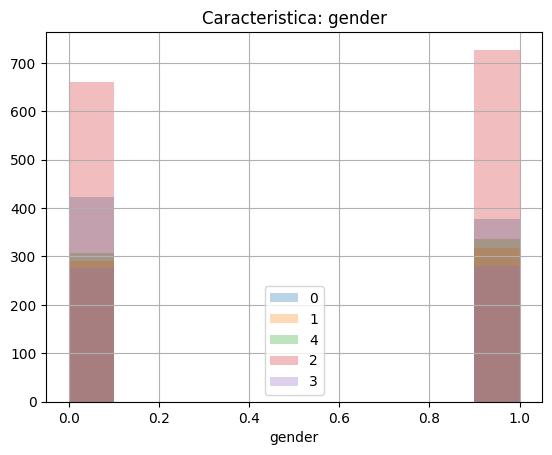

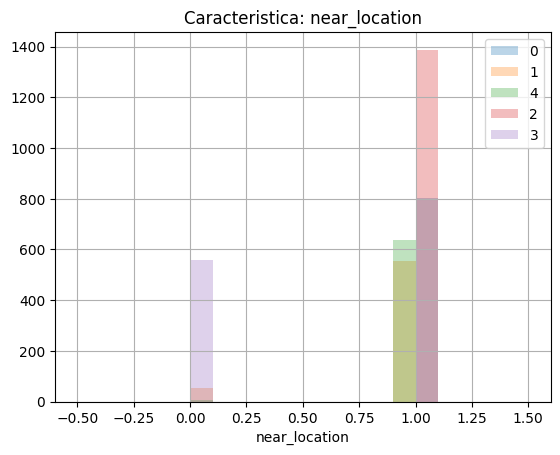

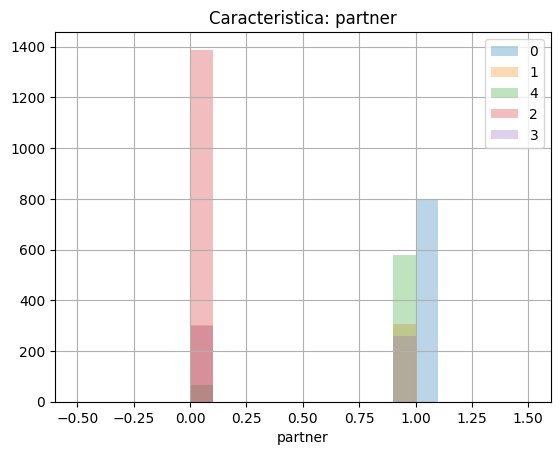

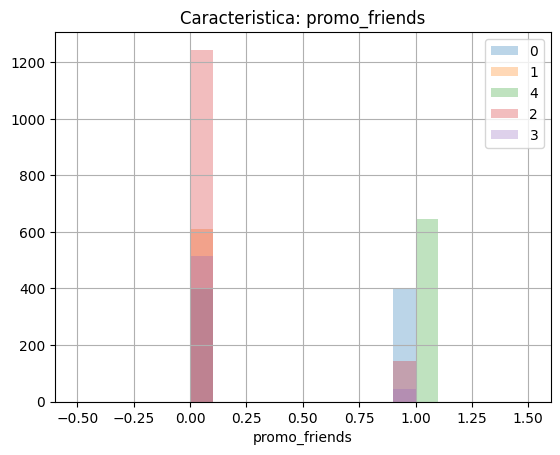

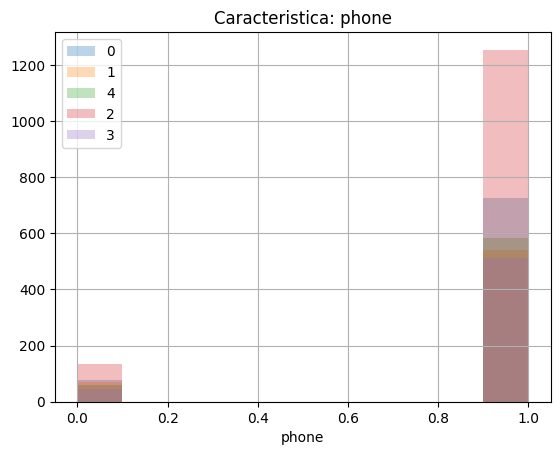

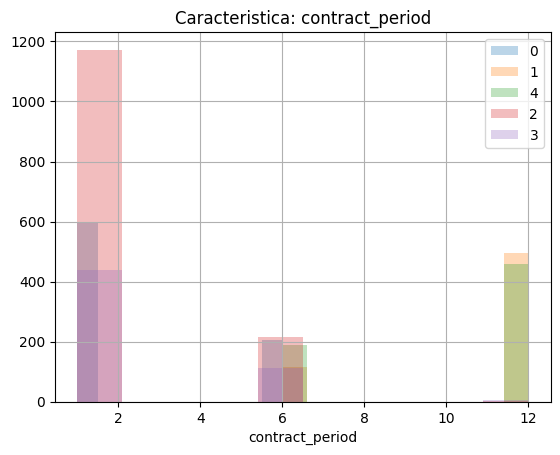

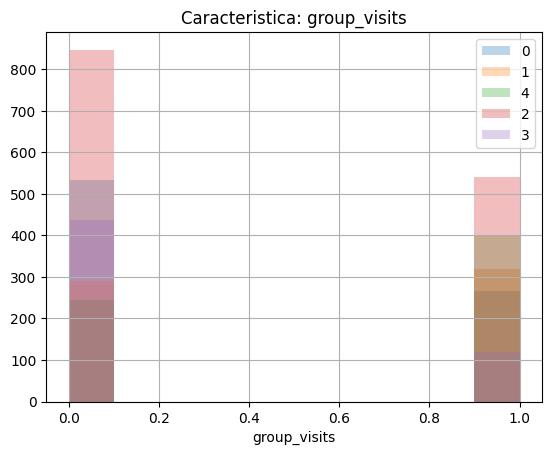

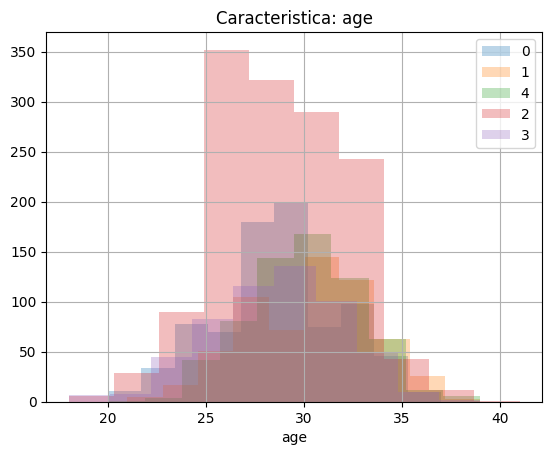

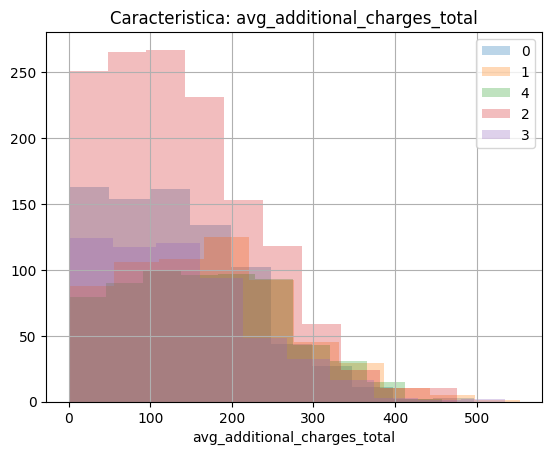

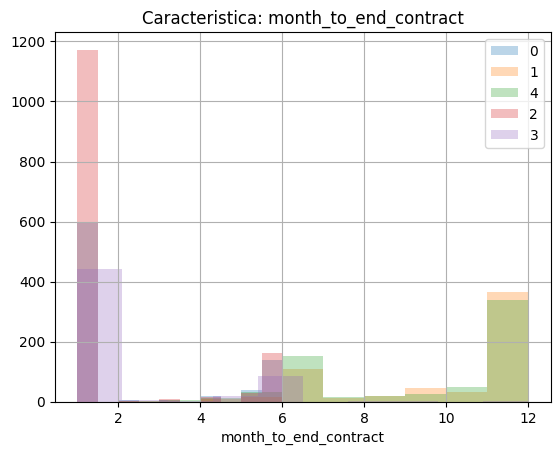

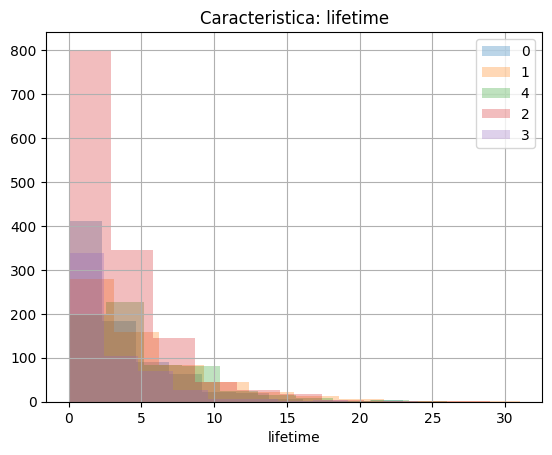

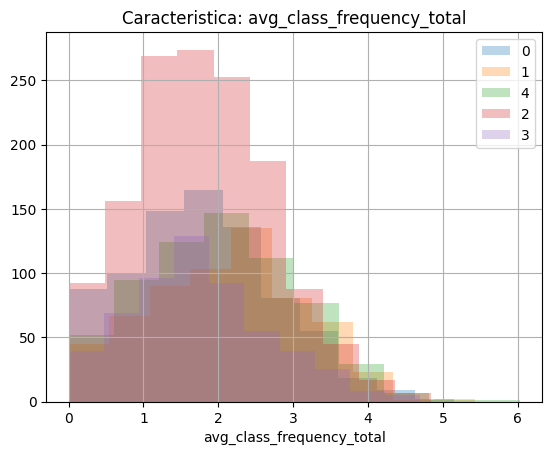

In [ ]:
# graficas e caracteristicas por etiqueta
for column in X.columns:
  for label in df['label'].unique():
    df[df['label']==label][column].hist(alpha=0.3, label=label)
  plt.title(f'Caracteristica: {column}')
  plt.xlabel(column)
  plt.legend()
  plt.show()


In [ ]:
print(df.groupby('label').mean().sort_values('churn', ascending=True))

         gender  near_location   partner  promo_friends     phone  \
label                                                               
2      0.578275       0.942492  0.469649       0.303514  0.830671   
1      0.512981       0.961504  0.787825       0.592659  0.905103   
0      0.521848       1.000000  0.298377       0.242197  0.910112   
3      0.496416       0.000000  0.467742       0.071685  0.917563   
4      0.488852       1.000000  0.346821       0.200661  0.909992   

       contract_period  group_visits        age  avg_additional_charges_total  \
label                                                                           
2             3.939297      0.396166  30.514377                    160.779605   
1            10.829006      0.541629  29.830797                    161.569772   
0             2.183521      1.000000  29.292135                    141.001738   
3             2.344086      0.213262  28.564516                    135.446713   
4             1.931462      0.

Los grupos con etiqueta 2 y 1 son los más leales, contrario a los grupos 3 y 4, que cuentan con las tasas de cancelación promedio más altas, 43.9% y 45.8% respectivamente.

Entre las características más determinantes podemos encontrar:
- Los clientes que pertenecen a la etiqueta 3 no tienen cerca su gimnasio.
- Los clientes más leales, el grupo 2, con una tasa de cancelación de 0, promedian 12 meses de membresía.
- El segundo grupo más leal, el grupo 1,  tiene en promedio contratos de casi 11 meses, seguido por el grupo 2 de casi 4 meses, mientras que los grupos 3 y 4  tienen en promedio contratos de 2 meses.
- Los grupos 2 y 1 tienen en promedio por cliente entre 20 y 25 dólares más en cargos adicionales que los grupos 3 y 4; puede significar que los grupos 2 y 1 incluyen beneficios extra en sus membresías.
- Usuarios del grupo 1 tienen un fuerte porcentaje (78.8%) de los mismos con empresas asociadas con el gimnasio.


# Conclusion general


Tomando en cuenta los resultados obtenidos en el análisis, presento las siguientes sugerencias:
- La cercanía al gimnasio es importante para los usuarios; posiblemente las campañas de marketing locales atraerían clientes más leales.
- Los clientes son más propensos a mantener su membresía si pasan de los 4 meses; sumado a esto, los usuarios más leales tienen contratos por periodos largos (4-10 meses). Se puede aprovechar esta observación y posiblemente implementar descuentos en contratos de duraciones extensas u otro tipo de estrategias para conseguir que el usuario mantenga su membresía por al menos 4-6 meses.
- Los cargos adicionales promedio parecen tener una influencia positiva en la lealtad de los usuarios; vale la pena investigar qué son estos cargos extras que los clientes menos leales no están utilizando y promover su consumo.
- Por último, la lealtad de los usuarios aumenta si la empresa en la que trabajan está afiliada con el gimnasio; por ende, tiene sentido buscar más empresas locales que quieran afiliarse con el gimnasio.